In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

In [1]:
import requests
import pandas as pd
from io import StringIO

# Extract the file ID from the Google Drive URL
file_id = '1_cB6mECcscH2gH-Q4VGXr8lFjbfdh7qt'

# Construct the file's download URL
url = f'https://drive.google.com/uc?id={file_id}'

# Send a GET request to fetch the file
response = requests.get(url)

# Ensure the request was successful
if response.status_code == 200:
    # Read the content as a CSV
    df = pd.read_csv(StringIO(response.text))
    print(df.head())
else:
    print(f"Failed to fetch the file. Status code: {response.status_code}")


          ID   Source  Severity           Start_Time             End_Time  \
0  A-5692717  source1         2  2021-09-21 07:28:30  2021-09-21 07:49:00   
1  A-4998592  source1         2  2023-01-16 18:25:00  2023-01-16 20:49:36   
2  A-5415384  source1         2                  NaN                  NaN   
3  A-6520851  source1         2  2021-01-09 01:25:00  2021-01-09 03:03:07   
4  A-6944798  source1         2  2020-10-15 11:24:00  2020-10-15 15:21:00   

   Start_Lat  Start_Lng    End_Lat    End_Lng  Distance(mi)  ... Roundabout  \
0  28.468802 -81.417358  28.472280 -81.417385         0.240  ...      False   
1  41.805696 -72.660086  41.784488 -72.660247         1.465  ...      False   
2  36.788364 -76.235809  36.776915 -76.230625         0.841  ...      False   
3  39.851439 -76.882758  39.852151 -76.875663         0.380  ...      False   
4  38.732405 -77.546155  38.739610 -77.525876         1.201  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop S

In [2]:
# Initial Data Understanding
print("\nBasic Information about the Dataset:\n")
df.info()


Basic Information about the Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127373 entries, 0 to 127372
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     127373 non-null  object 
 1   Source                 127373 non-null  object 
 2   Severity               127373 non-null  int64  
 3   Start_Time             105667 non-null  object 
 4   End_Time               105667 non-null  object 
 5   Start_Lat              127373 non-null  float64
 6   Start_Lng              127373 non-null  float64
 7   End_Lat                127373 non-null  float64
 8   End_Lng                127373 non-null  float64
 9   Distance(mi)           127373 non-null  float64
 10  Description            127373 non-null  object 
 11  Street                 127373 non-null  object 
 12  City                   127373 non-null  object 
 13  County                 127373 non-null  object 
 1

In [3]:
## Display the first few rows of the dataset
print("\nSample Data:\n")
display(df.head())


Sample Data:



,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-5692717,source1,2,2021-09-21 07:28:30,2021-09-21 07:49:00,28.468802,-81.417358,28.472280,-81.417385,0.240,...,False,False,False,False,False,False,day,day,day,day
1,A-4998592,source1,2,2023-01-16 18:25:00,2023-01-16 20:49:36,41.805696,-72.660086,41.784488,-72.660247,1.465,...,False,False,False,False,False,False,night,night,night,night
2,A-5415384,source1,2,NaN,NaN,36.788364,-76.235809,36.776915,-76.230625,0.841,...,False,False,False,False,False,False,day,day,day,day
3,A-6520851,source1,2,2021-01-09 01:25:00,2021-01-09 03:03:07,39.851439,-76.882758,39.852151,-76.875663,0.380,...,False,False,False,False,False,False,night,night,night,night
4,A-6944798,source1,2,2020-10-15 11:24:00,2020-10-15 15:21:00,38.732405,-77.546155,38.739610,-77.525876,1.201,...,False,False,False,False,False,False,day,day,day,day


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

C:\Users\anura\AppData\Local\Temp\ipykernel_4628\115774446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Severity", palette="viridis")


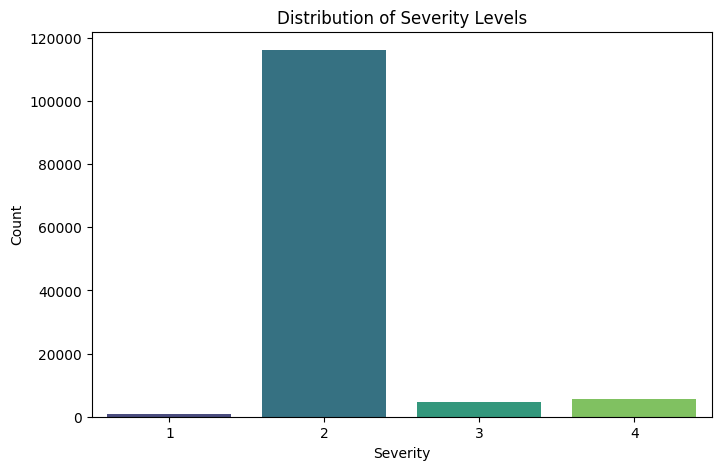

In [6]:
## Univariate Analysis: Severity Distribution
%matplotlib inline
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Severity", palette="viridis")
plt.title("Distribution of Severity Levels")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

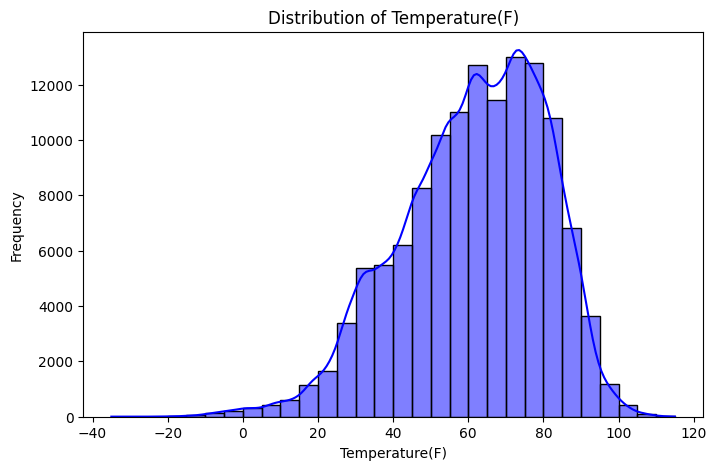

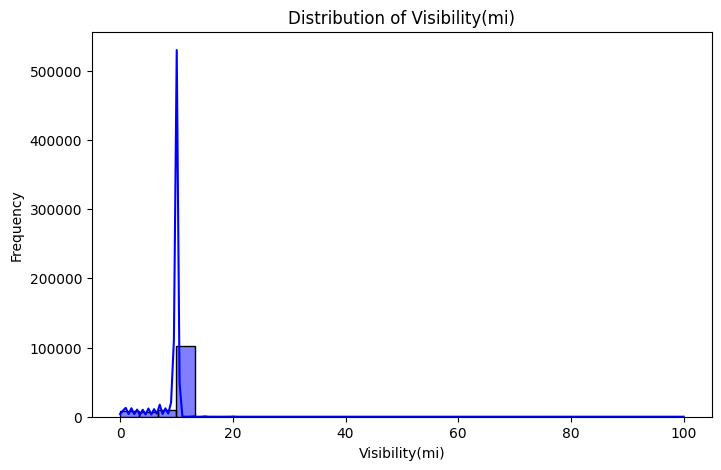

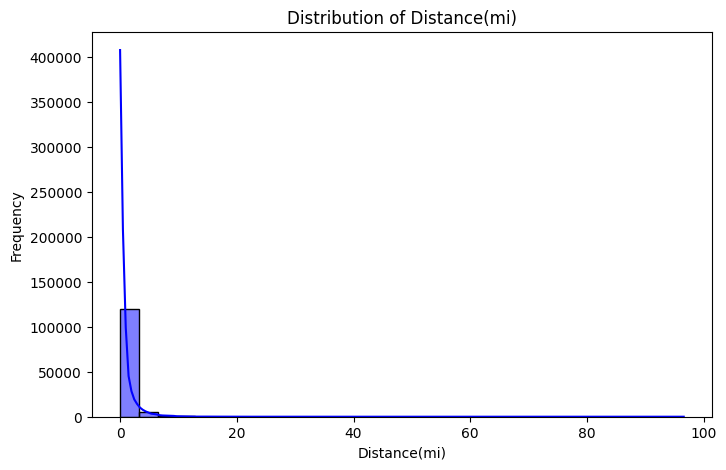

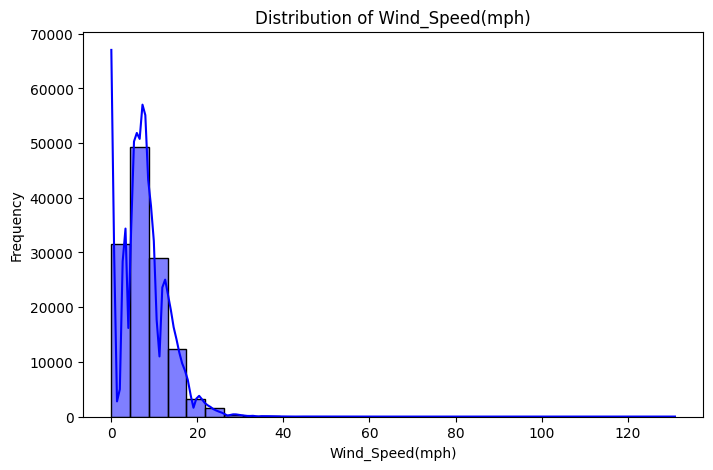

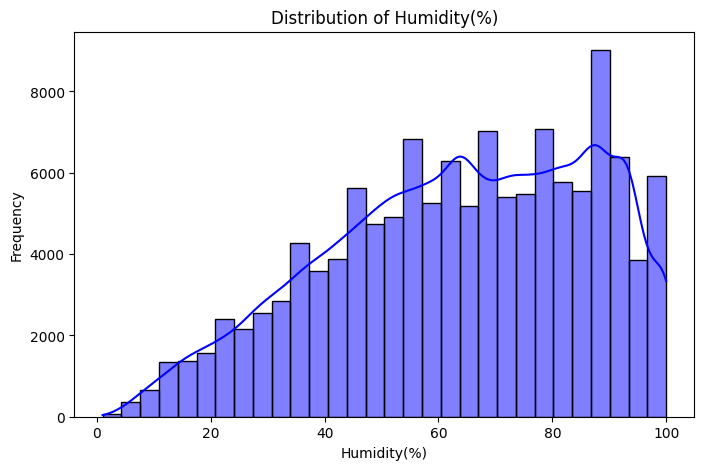

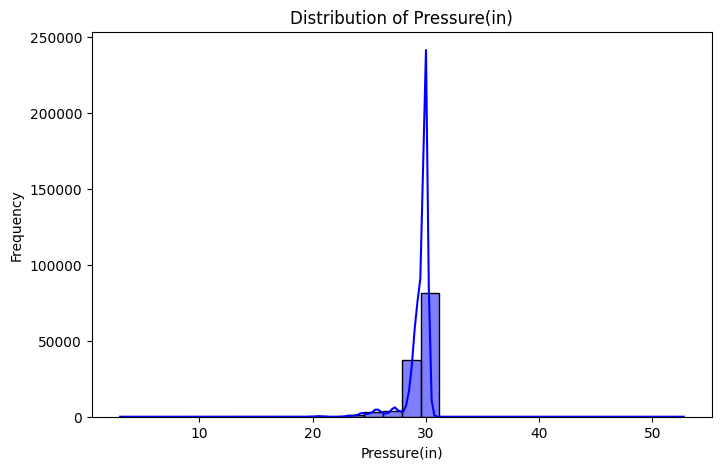

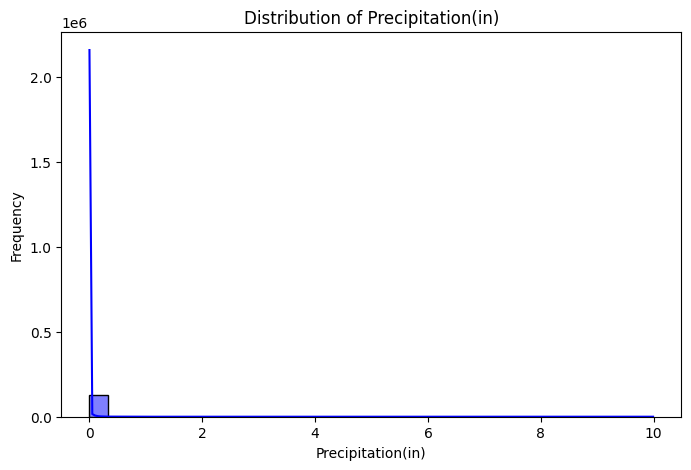

In [7]:
## Univariate Analysis: Numerical Features
numerical_features = [
    "Temperature(F)", "Visibility(mi)", "Distance(mi)", "Wind_Speed(mph)", "Humidity(%)", "Pressure(in)", "Precipitation(in)"
]

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [8]:
## Geospatial Analysis: Accident Density
map_data = df.dropna(subset=["Start_Lat", "Start_Lng"])
accident_map = folium.Map(location=[map_data["Start_Lat"].mean(), map_data["Start_Lng"].mean()], zoom_start=5)
HeatMap(data=map_data[["Start_Lat", "Start_Lng"]].values, radius=8).add_to(accident_map)
accident_map.save("accident_density_map.html")  

print("Geospatial Accident Density Map saved as 'accident_density_map.html'.")


Geospatial Accident Density Map saved as 'accident_density_map.html'.


C:\Users\anura\AppData\Local\Temp\ipykernel_4628\2182508021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


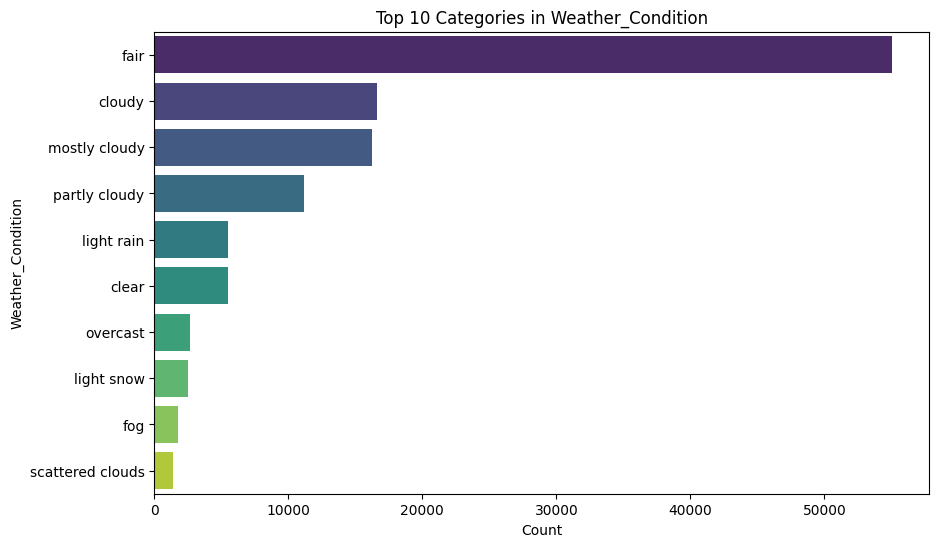

C:\Users\anura\AppData\Local\Temp\ipykernel_4628\2182508021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


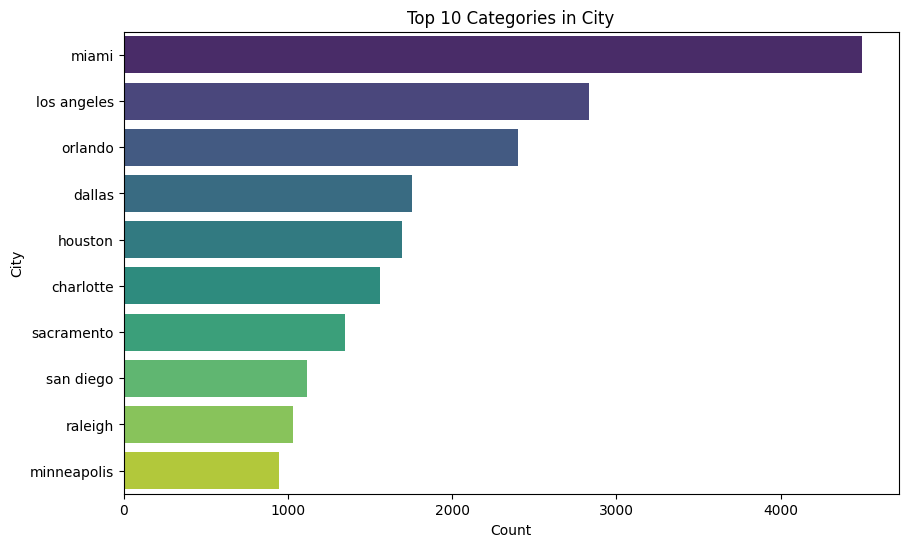

C:\Users\anura\AppData\Local\Temp\ipykernel_4628\2182508021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


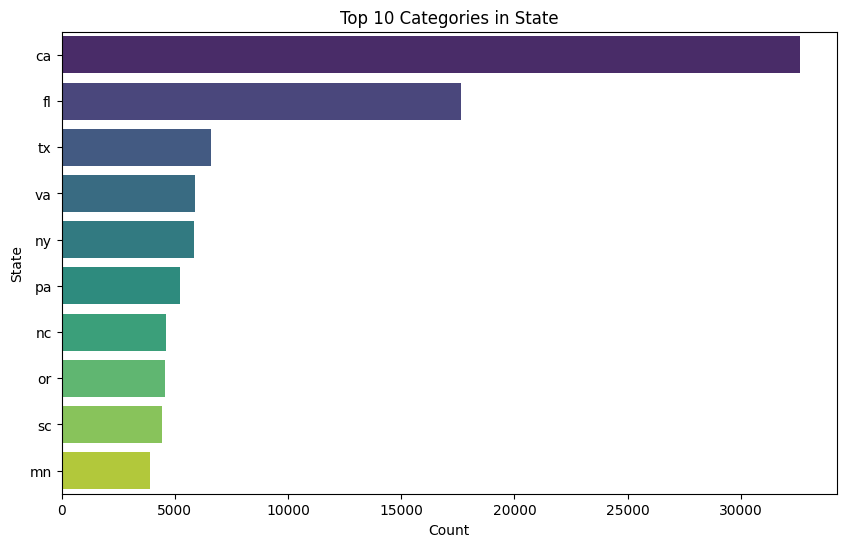

C:\Users\anura\AppData\Local\Temp\ipykernel_4628\2182508021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


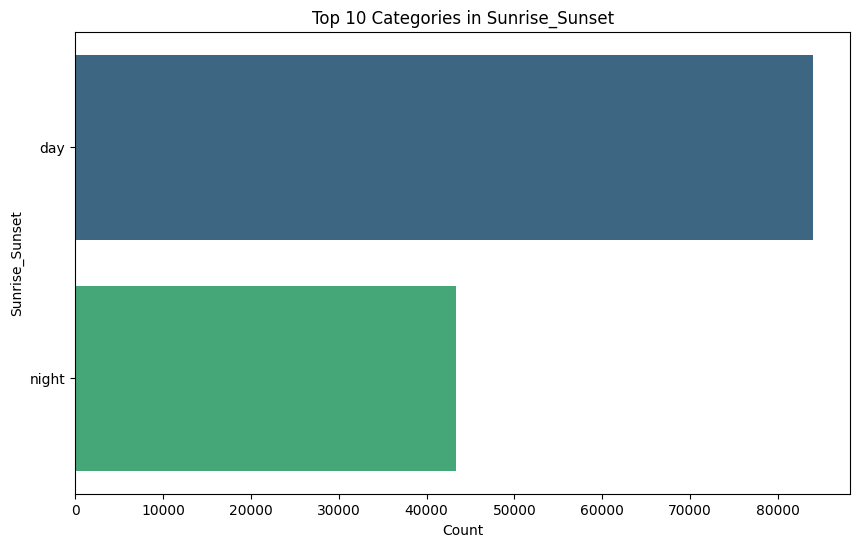

In [9]:
## Categorical Features Analysis
categorical_features = ["Weather_Condition", "City", "State", "Sunrise_Sunset"]

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    top_categories = df[feature].value_counts().nlargest(10)
    sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
    plt.title(f"Top 10 Categories in {feature}")
    plt.xlabel("Count")
    plt.ylabel(feature)
    plt.show()